In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import scipy
import os
from sklearn.linear_model import LinearRegression
import difflib
from matplotlib.colors import LinearSegmentedColormap, Normalize
from IPython.display import display, HTML
sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})
display(HTML("<style>.container { width:85% !important; }</style>"))
def get_sig(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

Inits.

In [1048]:
full_data = pd.read_pickle('multifiber.pickle')
# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
xpo_animals = ['4321L', '4321L2', '4321R', '7452R', '7452L2']
animals = np.concatenate([agg_animals, obs_animals, non_animals])
clusters = np.unique(full_data['91R2_d1_balbc_t1']['unsupervised labels'])
print(clusters)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]


### Computing and evaluating neural activity similarity between groups

In [ ]:
with open('sniffing_labels_dict.pkl', 'rb') as file:
    sniffing_labels = pickle.load(file)

behavior_groups = {
    'Self-directed': [0, 3],
    'Idle': [5],
    'Exploratory': [1, 2, 6],
    'Sniffing': [4],
}

ATTENTION_LABELS = behavior_groups['Sniffing']

animals = np.concatenate([agg_animals, obs_animals, non_animals, xpo_animals])

n_agg  = len(agg_animals)
n_obs  = len(obs_animals)
n_non  = len(non_animals)
n_xpo  = len(xpo_animals)

OBS_START = n_agg
OBS_END   = n_agg + n_obs

all_activity = np.zeros((len(clusters), len(region_ids), 27, len(animals)))
all_activity[:] = np.nan

sessions_missing_labels    = []   # unexpected: _obs_ session missing from sniffing_labels -> fell back to unfiltered
sessions_length_mismatch   = []   # attn array shorter than session -> fell back to unfiltered
sessions_no_attn_expected  = []   # expected: OBSmCD1, no labels by design -> unfiltered

for a, animal in enumerate(animals):

    is_obs = OBS_START <= a < OBS_END

    if a < n_agg:
        sessions = [x for x in list(full_data.keys()) if animal in x if '_balbc_' in x or '_mCD1_' in x]
    elif a < OBS_END:
        sessions = [x for x in list(full_data.keys()) if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
    elif a < OBS_END + n_non:
        sessions = [x for x in list(full_data.keys()) if animal in x if '_toy_' in x or '_toyCD1_' in x]
    else:
        sessions = [x for x in list(full_data.keys()) if animal in x if '_xpo_' in x or '_xpoCD1_' in x]

    for s, session in enumerate(sessions):

        sample = full_data[session]
        is_obsmcd1        = 'CD1' in session
        wants_attn_filter  = is_obs and not is_obsmcd1

        attn_mask = None
        if wants_attn_filter:
            attn = sniffing_labels.get(session, None)

            if attn is None:
                sessions_missing_labels.append(session)
                wants_attn_filter = False   # fall back to unfiltered rather than skip
            else:
                attn = np.asarray(attn)
                if len(attn) < sample.shape[0]:
                    sessions_length_mismatch.append(session)
                    wants_attn_filter = False   # fall back to unfiltered rather than skip
                else:
                    attn = attn[-sample.shape[0]:]
                    attn_mask = np.isin(attn, ATTENTION_LABELS)
        elif is_obs and is_obsmcd1:
            sessions_no_attn_expected.append(session)

        activity_per_cluster = np.zeros((len(clusters), all_activity.shape[1]))

        for i, c in enumerate(clusters):
            cluster_mask = (sample['unsupervised labels'].values == c)

            if wants_attn_filter:
                idxs2extract = np.where(cluster_mask & attn_mask)[0]
            else:
                idxs2extract = np.where(cluster_mask)[0]

            for r, roi in enumerate(region_ids):
                if len(idxs2extract) == 0 and 'CD1' in session:
                    activity_per_cluster[i, r] = 0 # enables full comparisons across all behaviors in hard fight; the lack of behavior is the point
                elif len(idxs2extract) == 0 and 'CD1' not in session:
                    activity_per_cluster[i, r] = np.nan # attn filtering makes some behaviors null
                else:
                    activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])

        all_activity[:, :, s, a] = activity_per_cluster

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_30264\1675639356.py:83: RuntimeWarning: Mean of empty slice
  activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])


Hard fight distributions

In [1077]:
# Compute cosine distances on a session-by-session level

from scipy.spatial import distance
from scipy.spatial.distance import cdist

def safe_cosine(a, b):
    if np.any(np.isnan(a)) or np.any(np.isnan(b)):
        return np.nan
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return np.nan
    return np.clip(1.0 - np.dot(a, b) / (norm_a * norm_b), 0, 2)

# --- Main loop ---
def create_cluster_vectors(grid, n_clusters, n_animals=12):
    EI_grid = np.zeros((len(n_clusters), 23, grid.shape[2], n_animals))
    EI_grid[:] = np.nan
    for a in range(grid.shape[-1]):
        for i, idx in enumerate(np.arange(23)):
            roi = grid[n_clusters, idx, :, a]
            EI_grid[:, i, :, a] = roi
    return EI_grid

n_clusters     = np.arange(13)
total_sessions = 27
n_rois         = len(region_ids)
n_animals      = len(animals)

activity_vectors = np.zeros((len(n_clusters), n_rois, 27, n_animals))
activity_vectors[:, :, :, :] = create_cluster_vectors(all_activity[:, :, :, :], n_clusters=np.array(n_clusters), n_animals=n_animals)

all_dists        = np.zeros((total_sessions, n_rois, n_animals, n_animals)); all_dists[:] = np.nan
all_cosines      = all_dists.copy()
all_soft_cosines = all_dists.copy()

for animal in np.arange(activity_vectors.shape[-1]):
    for roi in np.arange(n_rois):
        sample = activity_vectors[:, roi, :, animal]
        for second_animal in np.arange(activity_vectors.shape[-1]):
            if second_animal == animal:
                continue
            second_sample = activity_vectors[:, roi, :, second_animal]
            for session in np.arange(second_sample.shape[-1]):
                a = sample[:, session]
                b = second_sample[:, session]
                if np.all(np.isnan(b)):
                    continue
                all_cosines[session, roi, animal, second_animal] = safe_cosine(a, b)

In [1078]:
# Select data to compare - Hard fight

dist_vector = all_cosines.copy()
# Assessing distributions during hard fight
t1 = -3
t2 = None
obs_non = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, np.arange(21, 29)]
obs_aggro = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, :12]

In [1079]:
# Per-animal comparisons - each OBS animal yields an average of all comparisons to EXP or NON
# paired tests (same OBS animals in both AGG and NON comparisons)

from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

new_idx = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])

def adaptive_paired_test(a, b, alternative='two-sided', alpha=0.05):
    """
    Paired comparison: same OBS animals contribute both a (AGG-context) and
    b (NON-context) values. Normality of the DIFFERENCES gates paired
    t-test vs Wilcoxon signed-rank.
    """
    diffs = a - b
    n = len(diffs)

    if n >= 3:
        _, p_norm = shapiro(diffs)
        normal_diffs = p_norm > alpha
    else:
        normal_diffs = False
        p_norm = np.nan

    if normal_diffs:
        stat, p = ttest_rel(a, b, alternative=alternative)
        test_type = 't'
        df = n - 1
    else:
        try:
            stat, p = wilcoxon(a, b, alternative=alternative,
                               zero_method='wilcox', mode='auto')
        except ValueError:
            stat, p = np.nan, np.nan
        test_type = 'W'
        df = np.nan

    return stat, p, test_type, df, p_norm

p_values    = []
t_values    = []
test_types  = []
df_values   = []
n_animals_l = []

for r, roi in enumerate(region_ids):
    # ── collapse session axes per animal (axis 0 and axis 2), keep animal axis ──
    # obs_aggro[:, r] shape: (n_sessions_1, n_animals, n_sessions_2)
    agg_roi_activity = np.nanmean(obs_aggro[:, r], axis=(0, 2))
    non_roi_activity = np.nanmean(obs_non[:, r],   axis=(0, 2))

    if roi == 'MeA (E)' or roi == 'PA (E)': # MeA E and PA E in these two is just noise
        agg_roi_activity = agg_roi_activity[:-2] 
        non_roi_activity = non_roi_activity[:-2]

    # keep only animals with valid data at BOTH contexts (required for pairing)
    valid_mask = ~np.isnan(agg_roi_activity) & ~np.isnan(non_roi_activity)
    agg_clean  = agg_roi_activity[valid_mask]
    non_clean  = non_roi_activity[valid_mask]

    if len(agg_clean) >= 3:
        stat, p, test_type, df, norm_p = adaptive_paired_test(agg_clean, non_clean)
    else:
        stat, p, test_type, df, norm_p = np.nan, np.nan, 'n/a', np.nan, np.nan

    p_values.append(p)
    t_values.append(stat)
    test_types.append(test_type)
    df_values.append(df)
    n_animals_l.append(len(agg_clean))

# ── reorder to plotting order, then FDR-BH across all regions in this family ──
p_values    = np.asarray(p_values)[new_idx]
t_values    = np.asarray(t_values)[new_idx]
test_types  = np.asarray(test_types)[new_idx]
df_values   = np.asarray(df_values)[new_idx]
n_animals_l = np.asarray(n_animals_l)[new_idx]

valid_idx = [i for i, p in enumerate(p_values) if not np.isnan(p)]
p_adjusted = np.full(len(p_values), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests([p_values[i] for i in valid_idx], method='fdr_bh')
    for rank, i in enumerate(valid_idx):
        p_adjusted[i] = corr[rank]

# ── print + save stats ─────────────────────────────────────────────────────────
rows = []
for r, region in enumerate([region_ids[x] for x in new_idx]):
    df_str = f'{df_values[r]:.0f}' if not np.isnan(df_values[r]) else 'n/a'
    print('%s: %s = %f, df=%s, n=%d, p_raw = %f, p_fdr = %f'
          % (region, test_types[r], t_values[r], df_str, n_animals_l[r],
             p_values[r], p_adjusted[r]))
    rows.append('p = %f' % p_adjusted[r])

df = pd.DataFrame(rows, columns=['Values'])
# df.to_excel('data_list.xlsx', index=False)

VMHvl (E): t = -7.892931, df=8, n=9, p_raw = 0.000048, p_fdr = 0.000212
PMv (E): t = -4.351586, df=8, n=9, p_raw = 0.002440, p_fdr = 0.004625
AH (E): W = 1.000000, df=n/a, n=9, p_raw = 0.007812, p_fdr = 0.009549
POA (E): t = 1.880014, df=8, n=9, p_raw = 0.096903, p_fdr = 0.101518
MeA (E): t = -13.536322, df=6, n=7, p_raw = 0.000010, p_fdr = 0.000074
PA (E): t = -8.951502, df=6, n=7, p_raw = 0.000109, p_fdr = 0.000341
BNST (E): t = -12.663204, df=8, n=9, p_raw = 0.000001, p_fdr = 0.000016
lPAG (E): t = 3.469467, df=8, n=9, p_raw = 0.008449, p_fdr = 0.009783
vLS (E): t = -5.982838, df=8, n=9, p_raw = 0.000330, p_fdr = 0.000806
PrL (E): t = 4.038304, df=8, n=9, p_raw = 0.003745, p_fdr = 0.005371
LHb (E): W = 0.000000, df=n/a, n=9, p_raw = 0.003906, p_fdr = 0.005371
VMHvl (I): t = -8.879183, df=8, n=9, p_raw = 0.000020, p_fdr = 0.000113
PMv (I): t = -4.326847, df=8, n=9, p_raw = 0.002523, p_fdr = 0.004625
AH (I): t = 6.337229, df=8, n=9, p_raw = 0.000224, p_fdr = 0.000615
POA (I): t = -7.5

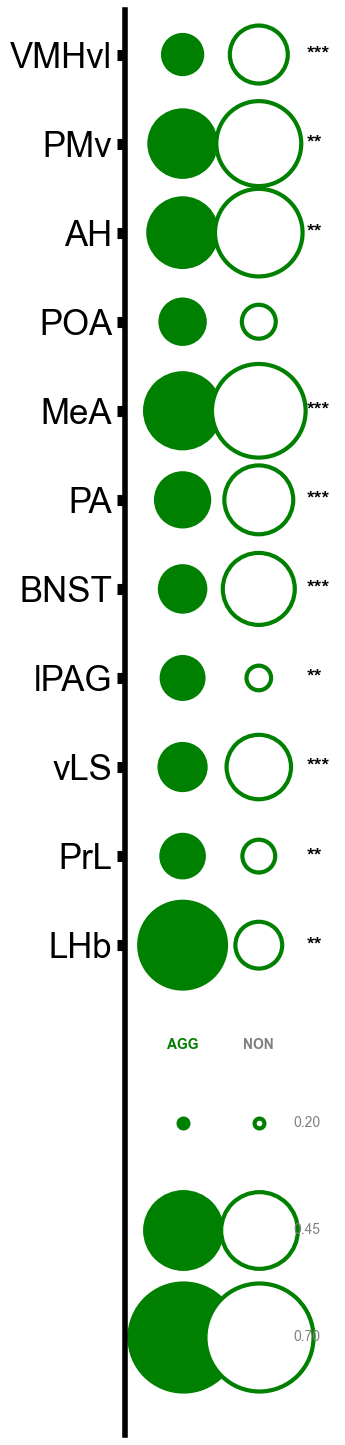

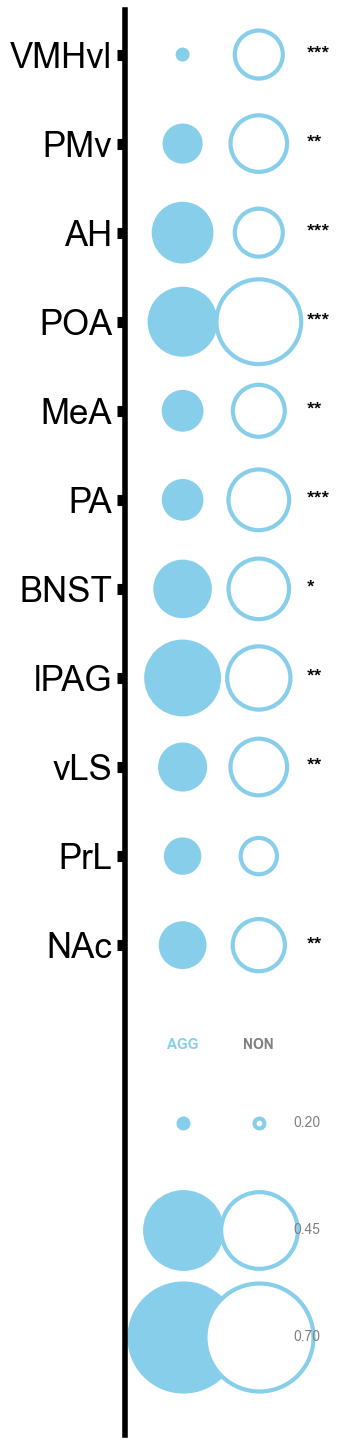

In [1080]:
np.set_printoptions(precision=4, suppress=True)
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
    'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
    'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
    'PA (E)', 'PA (I)', 'NAc (DA)']

# ── Bubble weights — SAME per-animal collapse as the paired stats test ───────
mean_func = np.nanmean   # summary across animals for display

def per_animal_region_weight(data, region_idx):
    """
    Collapse to one value per animal (mean over both session-like axes,
    matching the collapse used in the paired stats cell), then summarize
    across animals with mean_func. Ensures bubble size and significance
    stars are computed from the same underlying per-animal quantities.
    """
    per_animal = np.nanmean(data[:, region_idx], axis=(0, 2))   # (n_animals,)
    per_animal = per_animal[~np.isnan(per_animal)]
    if len(per_animal) == 0:
        return np.nan
    return mean_func(per_animal)

weights_aggro = np.array([per_animal_region_weight(obs_aggro, r)
                          for r in range(len(region_ids))])
weights_non   = np.array([per_animal_region_weight(obs_non, r)
                          for r in range(len(region_ids))])

vmin        = 0.2
vmax        = 0.7
size_factor = 6000

def get_sig_text(p_val):
    if np.isnan(p_val):  return ''
    if p_val == 0:       return '****'
    elif p_val < 0.001:  return '***'
    elif p_val < 0.01:   return '**'
    elif p_val < 0.05:   return '*'
    elif p_val <= 0.1:   return '#'
    else:                return ''

def add_inline_legend(ax, color, vmin, vmax, size_factor,
                      x_aggro, x_non, y_start=-2.5):
    """Draws a mini legend below the data using the same size scale."""
    legend_vals  = [vmin, (vmin + vmax) / 2, vmax]
    legend_sizes = (np.array(legend_vals) - vmin) / (vmax - vmin) * size_factor + 50
    y_leg        = y_start

    for val, sz in zip(legend_vals, legend_sizes):
        ax.scatter(x_aggro, y_leg, s=sz, facecolors=color,
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.scatter(x_non,   y_leg, s=sz, facecolors='white',
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.text(x_non + 0.18, y_leg, f'{val:.2f}',
                ha='left', va='center', fontsize=10, color='gray')
        y_leg -= 1.2

    ax.text(x_aggro, y_start + 0.8, 'AGG', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x_non,   y_start + 0.8, 'NON', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='gray')

# ── Excitatory (no NAc DA) ───────────────────────────────────────────────────
new_idx_E      = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])[::-1]  # removed 22
weights_aggro_E = weights_aggro[new_idx_E]
weights_non_E   = weights_non[new_idx_E]
labels_E        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_E]]

# ── p-values: pull directly by matching new_idx_E against the plotting order
#     used to build p_adjusted (i.e. p_adjusted[j] corresponds to region_ids[new_idx[j]])
pval_lookup = {region_idx: p_adjusted[j] for j, region_idx in enumerate(new_idx)}
pvals_E     = np.array([pval_lookup[r] for r in new_idx_E])

n_E    = len(new_idx_E)
y_pos  = np.arange(n_E)
x_agg  = 0.8
x_non  = 1.2
x_sig  = 1.45

sizes_aggro_E = (np.clip(weights_aggro_E, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_E   = (np.clip(weights_non_E,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_E) * x_agg, y_pos, s=sizes_aggro_E,
           facecolors='green', edgecolors='green', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_E) * x_non, y_pos, s=sizes_non_E,
           facecolors='white', edgecolors='green', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_E):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'green', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_E, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_E - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4_similarity_points_E_HF.svg', dpi=300)
plt.show()

# ── Inhibitory (with NAc DA appended) ────────────────────────────────────────
new_idx_I      = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])[::-1]  # added 22
weights_aggro_I = weights_aggro[new_idx_I]
weights_non_I   = weights_non[new_idx_I]
labels_I        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_I]]
pvals_I         = np.array([pval_lookup[r] for r in new_idx_I])

n_I    = len(new_idx_I)
y_pos_I = np.arange(n_I)

sizes_aggro_I = (np.clip(weights_aggro_I, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_I   = (np.clip(weights_non_I,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_I) * x_agg, y_pos_I, s=sizes_aggro_I,
           facecolors='skyblue', edgecolors='skyblue', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_I) * x_non, y_pos_I, s=sizes_non_I,
           facecolors='white', edgecolors='skyblue', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_I):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos_I[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'skyblue', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos_I)
ax.set_yticklabels(labels_I, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_I - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4_similarity_points_I_HF.svg', dpi=300)
plt.show()

In [1081]:
# ── Source data export: 4e_right ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

# ── Recompute per-animal clean arrays AND stats together, keyed by true
#    region index — same loop/logic as the stats cell, but retaining the
#    individual agg_clean/non_clean values rather than only the test output ──
per_region_data = {}

for r, roi in enumerate(region_ids):
    agg_roi_activity = np.nanmean(obs_aggro[:, r], axis=(0, 2))
    non_roi_activity = np.nanmean(obs_non[:, r],   axis=(0, 2))

    if roi == 'MeA (E)' or roi == 'PA (E)':
        agg_roi_activity = agg_roi_activity[:-2]
        non_roi_activity = non_roi_activity[:-2]

    valid_mask = ~np.isnan(agg_roi_activity) & ~np.isnan(non_roi_activity)
    agg_clean  = agg_roi_activity[valid_mask]
    non_clean  = non_roi_activity[valid_mask]

    if len(agg_clean) >= 3:
        stat, p, test_type, df, norm_p = adaptive_paired_test(agg_clean, non_clean)
    else:
        stat, p, test_type, df, norm_p = np.nan, np.nan, 'n/a', np.nan, np.nan

    per_region_data[r] = {
        'agg_clean': agg_clean, 'non_clean': non_clean,
        'stat': stat, 'p_raw': p, 'test_type': test_type, 'df': df,
    }

# ── attach FDR-corrected p (already computed in new_idx order upstream) ──────
p_fdr_lookup = {region_idx: p_adjusted[j] for j, region_idx in enumerate(new_idx)}

# ── build long-format table: all regions in new_idx, in that order,
#    covering both E-panel and I-panel membership plus true channel identity
#    (so NAc DA and LHb (E) are unambiguous regardless of which panel they
#    were plotted in) ───────────────────────────────────────────────────────
panel_E_set = set(new_idx_E if 'new_idx_E' in dir() else np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18]))
panel_I_set = set(new_idx_I if 'new_idx_I' in dir() else np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22]))

rows = []
for region_idx in new_idx:
    region_label = region_ids[region_idx].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
    channel = channel_from_label(region_ids[region_idx])
    panel = 'E' if region_idx in panel_E_set else ('I' if region_idx in panel_I_set else 'unassigned')

    d = per_region_data[region_idx]
    p_fdr = p_fdr_lookup[region_idx]

    for group_label, vals in [('EXP', d['agg_clean']), ('NON', d['non_clean'])]:
        for v in vals:
            rows.append({
                'region_idx': region_idx,
                'region': region_label,
                'channel': channel,
                'panel': panel,
                'group': group_label,
                'value': v,
                'test': d['test_type'],
                'stat': d['stat'],
                'df': d['df'],
                'n_paired': len(d['agg_clean']),
                'p_raw': d['p_raw'],
                'p_fdr': p_fdr,
                'sig': get_sig_text(p_fdr),
            })

sourceData_4e_left = pd.DataFrame(rows)
sourceData_4e_left.to_csv('./sourceData/4e_right.csv', index=False)

OBS-AGG: E vs I         paired t-test          stat=   3.477  df=   8  norm_p=0.3194  n=9  p_raw=0.0084  p_fdr=0.0125
E: OBS-AGG vs NON       paired t-test          stat=  -3.129  df=   8  norm_p=0.9989  n=9  p_raw=0.0140  p_fdr=0.0140
I: OBS-AGG vs NON       paired t-test          stat=  -5.774  df=   8  norm_p=0.9066  n=9  p_raw=0.0004  p_fdr=0.0013


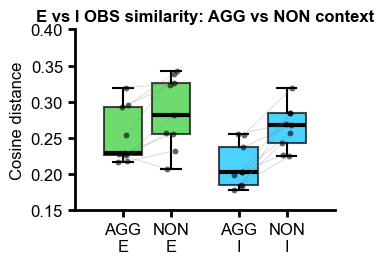

OBS-AGG: E vs I         paired t-test          stat=     3.477  df=   8  p_raw=8.3515e-03  p_fdr=1.2527e-02 *     n=  9
E: OBS-AGG vs NON       paired t-test          stat=    -3.129  df=   8  p_raw=1.4029e-02  p_fdr=1.4029e-02 *     n=  9
I: OBS-AGG vs NON       paired t-test          stat=    -5.774  df=   8  p_raw=4.1719e-04  p_fdr=1.2516e-03 **    n=  9


In [1082]:
from scipy.stats import ttest_rel, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests

plt.rcParams['font.family'] = 'Arial'

# --- Define idxs ---
I_idxs = np.array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21])
E_idxs = np.array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 20])

# --- Extract E vs I similarities ---
E_obs_aggro = obs_aggro[:, E_idxs]
E_obs_non   = obs_non[:, E_idxs]
I_obs_aggro = obs_aggro[:, I_idxs]
I_obs_non   = obs_non[:, I_idxs]

distb_EA = np.nanmedian(E_obs_aggro, axis=(0,1,3)).flatten()
distb_EN = np.nanmedian(E_obs_non,   axis=(0,1,3)).flatten()
distb_IA = np.nanmedian(I_obs_aggro, axis=(0,1,3)).flatten()
distb_IN = np.nanmedian(I_obs_non,   axis=(0,1,3)).flatten()

# --- Paired stats: 3 comparisons, same 9 OBS animals throughout ─────────────
def adaptive_paired_test(a, b, alternative='two-sided', alpha=0.05):
    """
    Paired comparison: same subjects contribute both a and b.
    Normality of the DIFFERENCES gates paired t-test vs Wilcoxon signed-rank.
    """
    diffs = a - b
    n = len(diffs)

    if n >= 3:
        _, p_norm = shapiro(diffs)
        normal_diffs = p_norm > alpha
    else:
        normal_diffs = False
        p_norm = np.nan

    if normal_diffs:
        stat, p = ttest_rel(a, b, alternative=alternative)
        test_type = 'paired t-test'
        df = n - 1
    else:
        try:
            stat, p = wilcoxon(a, b, alternative=alternative,
                               zero_method='wilcox', mode='auto')
        except ValueError:
            stat, p = np.nan, np.nan
        test_type = 'Wilcoxon signed-rank'
        df = np.nan

    return stat, p, test_type, df, p_norm


# only 3 comparisons — OBS-NON: E vs I dropped (not of interest)
comparisons = {
    'OBS-AGG: E vs I':    (distb_EA, distb_IA),
    'E: OBS-AGG vs NON':  (distb_EA, distb_EN),
    'I: OBS-AGG vs NON':  (distb_IA, distb_IN),
}

raw_p, stats_out = [], []
for label, (a, b) in comparisons.items():
    stat, p, test, df, norm_p = adaptive_paired_test(a, b)
    raw_p.append(p)
    stats_out.append({'label': label, 'stat': stat, 'p_raw': p, 'test': test,
                      'df': df, 'norm_p': norm_p, 'n': len(a)})

valid_idx = [i for i, p in enumerate(raw_p) if not np.isnan(p)]
p_corrected = np.full(len(raw_p), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests([raw_p[i] for i in valid_idx], method='fdr_bh')
    for rank, i in enumerate(valid_idx):
        p_corrected[i] = corr[rank]

for i, d in enumerate(stats_out):
    d['p_fdr'] = p_corrected[i]
    df_str = f'{d["df"]:.0f}' if not np.isnan(d['df']) else 'n/a'
    print(f"{d['label']:22s}  {d['test']:<22} stat={d['stat']:>8.3f}  df={df_str:>4}  "
          f"norm_p={d['norm_p']:.4f}  n={d['n']}  "
          f"p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f}")

# --- Plot: boxplot + individual animal overlay ───────────────────────────────
fig, ax_bar = plt.subplots(figsize=(4, 3.2))

box_data      = [distb_EA, distb_EN, distb_IA, distb_IN]
box_positions = [0, 0.5, 1.2, 1.7]
box_colors    = ['limegreen', 'limegreen', 'deepskyblue', 'deepskyblue']
xlabels       = ['AGG\nE', 'NON\nE', 'AGG\nI', 'NON\nI']

bp = ax_bar.boxplot(box_data, positions=box_positions, widths=0.4,
                    patch_artist=True,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=3),
                    boxprops=dict(linewidth=1.5, edgecolor='black'),
                    whiskerprops=dict(linewidth=1.5, color='black'),
                    capprops=dict(linewidth=1.5, color='black'))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_bar.set_xticks(box_positions)
ax_bar.set_xticklabels(xlabels, fontsize=11)

# ── overlay individual animals, jittered, with light lines connecting paired points ──
rng = np.random.default_rng(42)
n_animals = len(distb_EA)
jitter_by_animal = rng.uniform(-0.06, 0.06, size=n_animals)

for xpos, data in zip(box_positions, box_data):
    ax_bar.scatter(np.full(n_animals, xpos) + jitter_by_animal, data,
                   color='black', s=18, alpha=0.6, zorder=5, linewidths=0)

# connect paired animals within each of the 3 tested comparisons
pair_connections = [
    (0, 1),   # AGG E vs NON E
    (2, 3),   # AGG I vs NON I
]
for i1, i2 in pair_connections:
    x1, x2 = box_positions[i1], box_positions[i2]
    d1, d2 = box_data[i1], box_data[i2]
    for a in range(n_animals):
        ax_bar.plot([x1 + jitter_by_animal[a], x2 + jitter_by_animal[a]],
                   [d1[a], d2[a]], color='gray', alpha=0.25, linewidth=0.8, zorder=3)

def draw_bracket(ax, x1, x2, y, p, h=0.005):
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           sig = 'ns'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11)

def whisker_top(d):
    q1, q3 = np.percentile(d, [25, 75])
    iqr = q3 - q1
    return min(np.max(d), q3 + 1.5 * iqr)

ymax = max(whisker_top(d) for d in box_data)
step = ymax * 0.06

# draw_bracket(ax_bar, box_positions[0], box_positions[2], ymax + step,   stats_out[0]['p_fdr'])
# draw_bracket(ax_bar, box_positions[0], box_positions[1], ymax + step*3, stats_out[1]['p_fdr'])
# draw_bracket(ax_bar, box_positions[2], box_positions[3], ymax + step*5, stats_out[2]['p_fdr'])

ax_bar.set_ylabel('Cosine distance', fontsize=12)
ax_bar.set_title('E vs I OBS similarity: AGG vs NON context',
                 fontsize=12, fontweight='bold')

ax_bar.tick_params(axis='both', labelsize=12, width=2, length=5)
for spine in ax_bar.spines.values():
    spine.set_linewidth(2)

plt.ylim(bottom=0.15, top=0.4)
sns.despine(ax=ax_bar)
plt.tight_layout()
plt.savefig('.\\figures\\fig4_obs_non_aggro_E_vs_I_comparison_HF.svg', dpi=300)
plt.show()

# --- Print summary ────────────────────────────────────────────────────────────
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

for i, d in enumerate(stats_out):
    label = d['label']
    a, b  = list(comparisons.values())[i]
    sig   = get_sig(d['p_fdr'])
    df_str = f'{d["df"]:.0f}' if not np.isnan(d['df']) else 'n/a'
    print(f"{label:<22}  {d['test']:<22} stat={d['stat']:>10.3f}  df={df_str:>4}  "
          f"p_raw={d['p_raw']:.4e}  p_fdr={d['p_fdr']:.4e} {sig:<4}  "
          f"n={d['n']:>3}")

In [1083]:
stat_by_label = {d['label']: d for d in stats_out}

rows = []

for channel_label, agg_vals, non_vals, comp_label in [
    ('E', distb_EA, distb_EN, 'E: OBS-AGG vs NON'),
    ('I', distb_IA, distb_IN, 'I: OBS-AGG vs NON'),
]:
    sr = stat_by_label[comp_label]
    for animal_idx in range(len(agg_vals)):
        rows.append({
            'channel': channel_label,
            'animal_idx': animal_idx,
            'AGG_context_cosine_distance': agg_vals[animal_idx],
            'NON_context_cosine_distance': non_vals[animal_idx],
            'test_type': sr['test'],
            'stat': sr['stat'],
            'df': sr['df'],
            'n_paired_animals': sr['n'],
            'p_raw': sr['p_raw'],
            'p_fdr': sr['p_fdr'],
        })

# ── E vs I (AGG-context only) comparison — separate structure, not paired
#    against the same axis as above; kept as its own block with its own stats
sr_ei = stat_by_label['OBS-AGG: E vs I']
for animal_idx in range(len(distb_EA)):
    rows.append({
        'channel': 'E_vs_I_AGG_context',
        'animal_idx': animal_idx,
        'AGG_context_cosine_distance': distb_EA[animal_idx],
        'NON_context_cosine_distance': distb_IA[animal_idx],  # here "NON_context" col actually holds I-channel AGG value — see note below
        'test_type': sr_ei['test'],
        'stat': sr_ei['stat'],
        'df': sr_ei['df'],
        'n_paired_animals': sr_ei['n'],
        'p_raw': sr_ei['p_raw'],
        'p_fdr': sr_ei['p_fdr'],
    })

sourceData_4g_right = pd.DataFrame(rows)
sourceData_4g_right.to_csv('./sourceData/4g_right.csv', index=False)

Training period distributions

In [1056]:
# Calculate cross-animal similarity matrices for different cluster numbers - Training period
# Soft cosine relaxation restricted to aggression (conflict) clusters only,
# averaging happens downstream, not here.

# ── Soft cosine matrix — relaxation restricted to same-family clusters ────────

aggression_clusters   =  [0, 1, 2, 3]
investigative_clusters = [4, 6, 7, 8]
asocial_clusters       = [5, 9, 10, 11, 12]

def build_family_relaxed_matrix(n_clusters, families, neighbor_sim=0.5):
    S = np.eye(n_clusters)
    for group in families:
        for i in group:
            for j in group:
                if i != j:
                    S[i, j] = neighbor_sim
    return S

S_full_family = build_family_relaxed_matrix(
    13, [aggression_clusters, investigative_clusters, asocial_clusters], neighbor_sim=0.5)


def soft_cosine_pairwise_complete(a, b, S, min_valid_dims=5):
    """
    Soft cosine restricted to dimensions where BOTH a and b have valid
    (non-NaN) data. Rather than requiring the full vector to be complete,
    only compares the shared subset of clusters — treating a missing
    cluster as "no data for this dimension," not as zero activity.

    min_valid_dims: minimum number of jointly-valid clusters required to
    compute a meaningful comparison; returns NaN below this threshold
    (protects against spuriously high/low similarity computed from only
    1-2 shared dimensions).
    """
    valid = ~np.isnan(a) & ~np.isnan(b)
    if valid.sum() < min_valid_dims:
        return np.nan

    a_v = a[valid] - np.nanmean(a[valid])
    b_v = b[valid] - np.nanmean(b[valid])
    S_v = S[np.ix_(valid, valid)]   # restrict S to the jointly-valid dimensions

    num   = a_v @ S_v @ b_v
    denom = np.sqrt((a_v @ S_v @ a_v) * (b_v @ S_v @ b_v))
    if denom == 0:
        return np.nan
    return np.clip(1 - num / denom, 0, 2)

def safe_cosine_pairwise_complete(a, b, min_valid_dims=5):
    """Pairwise-complete version of the standard (hard) cosine, matching
    the same missing-data handling as soft_cosine_pairwise_complete."""
    valid = ~np.isnan(a) & ~np.isnan(b)
    if valid.sum() < min_valid_dims:
        return np.nan

    a_v = a[valid] - np.nanmean(a[valid])
    b_v = b[valid] - np.nanmean(b[valid])
    denom = np.linalg.norm(a_v) * np.linalg.norm(b_v)
    if denom == 0:
        return np.nan
    return np.clip(1 - (a_v @ b_v) / denom, 0, 2)

# Formatting — SESSION level
n_clusters      = np.arange(13)
total_sessions  = 27
n_rois          = len(region_ids)
n_animals       = len(animals)

activity_vectors = np.zeros((len(n_clusters), n_rois, total_sessions, n_animals))
activity_vectors[:, :, :, :] = create_cluster_vectors(
    all_activity[:, :, :, :], n_clusters=np.array(n_clusters), n_animals=n_animals)

# For saving — session resolution
all_dists = np.zeros((total_sessions, n_rois, n_animals, n_animals))
all_dists[:] = np.nan
all_soft_cosines_TP = all_dists.copy()
all_cosines_TP      = all_dists.copy()

for animal in np.arange(activity_vectors.shape[-1]):
    for roi in np.arange(n_rois):
        sample = activity_vectors[:, roi, :, animal]
        for second_animal in np.arange(activity_vectors.shape[-1]):
            if second_animal == animal:
                continue
            second_sample = activity_vectors[:, roi, :, second_animal]
            for session in np.arange(3): # all training period
                if np.all(np.isnan(second_sample[:, session])):
                    continue
                all_cosines_TP[session, roi, animal, second_animal] = safe_cosine_pairwise_complete(
                    sample[:, session], second_sample[:, session])
                all_soft_cosines_TP[session, roi, animal, second_animal] = soft_cosine_pairwise_complete(
                    sample[:, session], second_sample[:, session], S_full_family)

In [1069]:
# Select data to compare - Training period, day 1

dist_vector = all_soft_cosines_TP.copy()
t1 = 0
t2 = 3
obs_non   = dist_vector[t1:t2, :, np.arange(12, 21), :][:, :, :, np.arange(21, 29)]
obs_aggro = dist_vector[t1:t2, :, np.arange(12, 21), :][:, :, :, :12]

In [1070]:
# Per-animal comparisons - each OBS animal yields an average of all comparisons to EXP or NON
# paired tests (same OBS animals in both AGG and NON comparisons)

from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

new_idx = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])

def adaptive_paired_test(a, b, alternative='less', alpha=0.05):
    """
    Paired comparison: same OBS animals contribute both a (AGG-context) and
    b (NON-context) values. Normality of the DIFFERENCES gates paired
    t-test vs Wilcoxon signed-rank.
    """
    diffs = a - b
    n = len(diffs)

    if n >= 3:
        _, p_norm = shapiro(diffs)
        normal_diffs = p_norm > alpha
    else:
        normal_diffs = False
        p_norm = np.nan

    if normal_diffs:
        stat, p = ttest_rel(a, b, alternative=alternative)
        test_type = 't'
        df = n - 1
    else:
        try:
            stat, p = wilcoxon(a, b, alternative=alternative,
                               zero_method='wilcox', mode='auto')
        except ValueError:
            stat, p = np.nan, np.nan
        test_type = 'W'
        df = np.nan

    return stat, p, test_type, df, p_norm

p_values    = []
t_values    = []
test_types  = []
df_values   = []
n_animals_l = []

for r, roi in enumerate(region_ids):
    # ── collapse session axes per animal (axis 0 and axis 2), keep animal axis ──
    # obs_aggro[:, r] shape: (n_sessions_1, n_animals, n_sessions_2)
    agg_roi_activity = np.nanmean(obs_aggro[:, r], axis=(0, 2))
    non_roi_activity = np.nanmean(obs_non[:, r],   axis=(0, 2))

    if roi == 'MeA (E)' or roi == 'PA (E)': # MeA E and PA E in these two is just noise
        agg_roi_activity = agg_roi_activity[:-2] 
        non_roi_activity = non_roi_activity[:-2]

    # keep only animals with valid data at BOTH contexts (required for pairing)
    valid_mask = ~np.isnan(agg_roi_activity) & ~np.isnan(non_roi_activity)
    agg_clean  = agg_roi_activity[valid_mask]
    non_clean  = non_roi_activity[valid_mask]

    if len(agg_clean) >= 3:
        stat, p, test_type, df, norm_p = adaptive_paired_test(agg_clean, non_clean)
    else:
        stat, p, test_type, df, norm_p = np.nan, np.nan, 'n/a', np.nan, np.nan

    p_values.append(p)
    t_values.append(stat)
    test_types.append(test_type)
    df_values.append(df)
    n_animals_l.append(len(agg_clean))

# ── reorder to plotting order, then FDR-BH across all regions in this family ──
p_values    = np.asarray(p_values)[new_idx]
t_values    = np.asarray(t_values)[new_idx]
test_types  = np.asarray(test_types)[new_idx]
df_values   = np.asarray(df_values)[new_idx]
n_animals_l = np.asarray(n_animals_l)[new_idx]

valid_idx = [i for i, p in enumerate(p_values) if not np.isnan(p)]
p_adjusted = np.full(len(p_values), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests([p_values[i] for i in valid_idx], method='fdr_bh')
    for rank, i in enumerate(valid_idx):
        p_adjusted[i] = corr[rank]

# ── print + save stats ─────────────────────────────────────────────────────────
rows = []
for r, region in enumerate([region_ids[x] for x in new_idx]):
    df_str = f'{df_values[r]:.0f}' if not np.isnan(df_values[r]) else 'n/a'
    print('%s: %s = %f, df=%s, n=%d, p_raw = %f, p_fdr = %f'
          % (region, test_types[r], t_values[r], df_str, n_animals_l[r],
             p_values[r], p_adjusted[r]))
    rows.append('p = %f' % p_adjusted[r])

df = pd.DataFrame(rows, columns=['Values'])
# df.to_excel('data_list.xlsx', index=False)

VMHvl (E): t = -3.395120, df=8, n=9, p_raw = 0.004714, p_fdr = 0.007408
PMv (E): t = -3.269086, df=8, n=9, p_raw = 0.005686, p_fdr = 0.007818
AH (E): t = -4.639620, df=8, n=9, p_raw = 0.000834, p_fdr = 0.002620
POA (E): t = -7.593008, df=8, n=9, p_raw = 0.000032, p_fdr = 0.000175
MeA (E): t = -2.754833, df=6, n=7, p_raw = 0.016540, p_fdr = 0.019151
PA (E): t = -4.006465, df=6, n=7, p_raw = 0.003533, p_fdr = 0.006478
BNST (E): t = -9.631271, df=8, n=9, p_raw = 0.000006, p_fdr = 0.000062
lPAG (E): t = -3.529098, df=8, n=9, p_raw = 0.003871, p_fdr = 0.006551
vLS (E): t = -4.172600, df=8, n=9, p_raw = 0.001555, p_fdr = 0.003802
PrL (E): t = -2.802909, df=8, n=9, p_raw = 0.011547, p_fdr = 0.014113
LHb (E): t = -0.774038, df=8, n=9, p_raw = 0.230584, p_fdr = 0.230584
VMHvl (I): t = -6.046141, df=8, n=9, p_raw = 0.000154, p_fdr = 0.000676
PMv (I): t = -4.975624, df=8, n=9, p_raw = 0.000543, p_fdr = 0.001990
AH (I): t = -3.293009, df=8, n=9, p_raw = 0.005486, p_fdr = 0.007818
POA (I): t = -3.9

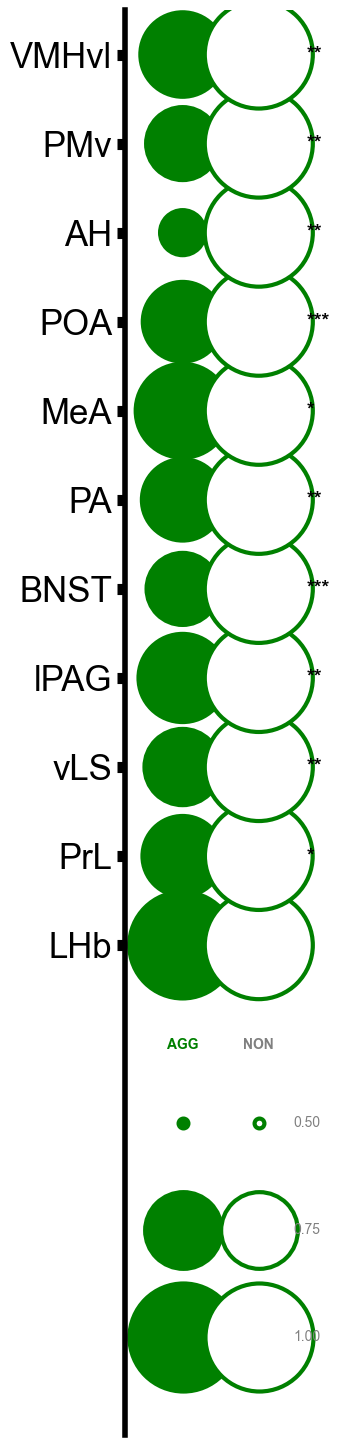

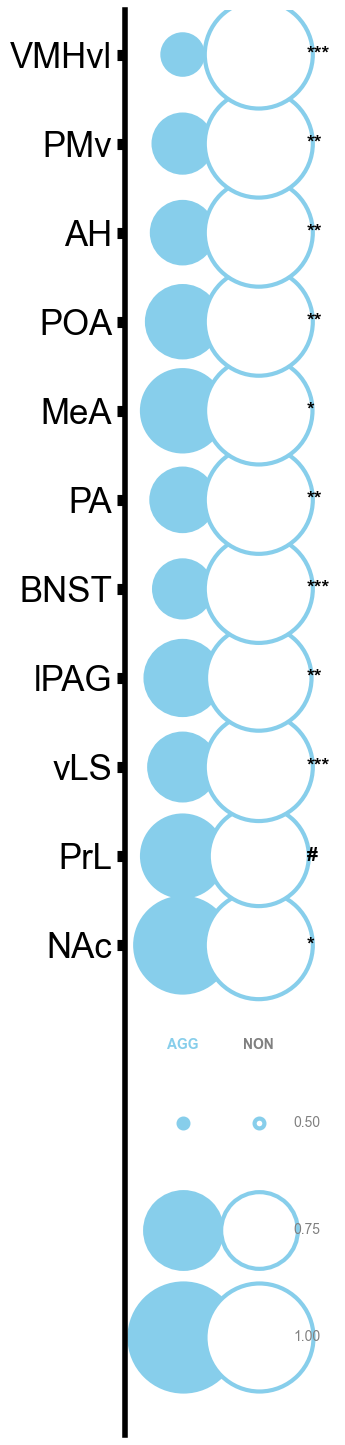

In [1071]:
np.set_printoptions(precision=4, suppress=True)
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
    'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
    'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
    'PA (E)', 'PA (I)', 'NAc (DA)']

# ── Bubble weights — SAME per-animal collapse as the paired stats test ───────
mean_func = np.nanmedian   # summary across animals for display

def per_animal_region_weight(data, region_idx):
    """
    Collapse to one value per animal (mean over both session-like axes,
    matching the collapse used in the paired stats cell), then summarize
    across animals with mean_func. Ensures bubble size and significance
    stars are computed from the same underlying per-animal quantities.
    """
    per_animal = np.nanmean(data[:, region_idx], axis=(0, 2))   # (n_animals,)
    per_animal = per_animal[~np.isnan(per_animal)]
    if len(per_animal) == 0:
        return np.nan
    return mean_func(per_animal)

weights_aggro = np.array([per_animal_region_weight(obs_aggro, r)
                          for r in range(len(region_ids))])
weights_non   = np.array([per_animal_region_weight(obs_non, r)
                          for r in range(len(region_ids))])

vmin        = 0.5
vmax        =1.
size_factor = 6000

def get_sig_text(p_val):
    if np.isnan(p_val):  return ''
    if p_val == 0:       return '****'
    elif p_val < 0.001:  return '***'
    elif p_val < 0.01:   return '**'
    elif p_val < 0.05:   return '*'
    elif p_val <= 0.1:   return '#'
    else:                return ''

def add_inline_legend(ax, color, vmin, vmax, size_factor,
                      x_aggro, x_non, y_start=-2.5):
    """Draws a mini legend below the data using the same size scale."""
    legend_vals  = [vmin, (vmin + vmax) / 2, vmax]
    legend_sizes = (np.array(legend_vals) - vmin) / (vmax - vmin) * size_factor + 50
    y_leg        = y_start

    for val, sz in zip(legend_vals, legend_sizes):
        ax.scatter(x_aggro, y_leg, s=sz, facecolors=color,
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.scatter(x_non,   y_leg, s=sz, facecolors='white',
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.text(x_non + 0.18, y_leg, f'{val:.2f}',
                ha='left', va='center', fontsize=10, color='gray')
        y_leg -= 1.2

    ax.text(x_aggro, y_start + 0.8, 'AGG', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x_non,   y_start + 0.8, 'NON', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='gray')

# ── Excitatory (no NAc DA) ───────────────────────────────────────────────────
new_idx_E      = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])[::-1]  # removed 22
weights_aggro_E = weights_aggro[new_idx_E]
weights_non_E   = weights_non[new_idx_E]
labels_E        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_E]]

# ── p-values: pull directly by matching new_idx_E against the plotting order
#     used to build p_adjusted (i.e. p_adjusted[j] corresponds to region_ids[new_idx[j]])
pval_lookup = {region_idx: p_adjusted[j] for j, region_idx in enumerate(new_idx)}
pvals_E     = np.array([pval_lookup[r] for r in new_idx_E])

n_E    = len(new_idx_E)
y_pos  = np.arange(n_E)
x_agg  = 0.8
x_non  = 1.2
x_sig  = 1.45

sizes_aggro_E = (np.clip(weights_aggro_E, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_E   = (np.clip(weights_non_E,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_E) * x_agg, y_pos, s=sizes_aggro_E,
           facecolors='green', edgecolors='green', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_E) * x_non, y_pos, s=sizes_non_E,
           facecolors='white', edgecolors='green', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_E):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'green', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_E, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_E - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4_similarity_points_E_TP.svg', dpi=300)
plt.show()

# ── Inhibitory (with NAc DA appended) ────────────────────────────────────────
new_idx_I      = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])[::-1]  # added 22
weights_aggro_I = weights_aggro[new_idx_I]
weights_non_I   = weights_non[new_idx_I]
labels_I        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_I]]
pvals_I         = np.array([pval_lookup[r] for r in new_idx_I])

n_I    = len(new_idx_I)
y_pos_I = np.arange(n_I)

sizes_aggro_I = (np.clip(weights_aggro_I, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_I   = (np.clip(weights_non_I,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_I) * x_agg, y_pos_I, s=sizes_aggro_I,
           facecolors='skyblue', edgecolors='skyblue', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_I) * x_non, y_pos_I, s=sizes_non_I,
           facecolors='white', edgecolors='skyblue', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_I):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos_I[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'skyblue', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos_I)
ax.set_yticklabels(labels_I, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_I - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4_similarity_points_I_TP.svg', dpi=300)
plt.show()

In [1074]:
# ── Source data export: 4e_left ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

# ── Recompute per-animal clean arrays AND stats together, keyed by true
#    region index — same loop/logic as the stats cell, but retaining the
#    individual agg_clean/non_clean values rather than only the test output ──
per_region_data = {}

for r, roi in enumerate(region_ids):
    agg_roi_activity = np.nanmean(obs_aggro[:, r], axis=(0, 2))
    non_roi_activity = np.nanmean(obs_non[:, r],   axis=(0, 2))

    if roi == 'MeA (E)' or roi == 'PA (E)':
        agg_roi_activity = agg_roi_activity[:-2]
        non_roi_activity = non_roi_activity[:-2]

    valid_mask = ~np.isnan(agg_roi_activity) & ~np.isnan(non_roi_activity)
    agg_clean  = agg_roi_activity[valid_mask]
    non_clean  = non_roi_activity[valid_mask]

    if len(agg_clean) >= 3:
        stat, p, test_type, df, norm_p = adaptive_paired_test(agg_clean, non_clean)
    else:
        stat, p, test_type, df, norm_p = np.nan, np.nan, 'n/a', np.nan, np.nan

    per_region_data[r] = {
        'agg_clean': agg_clean, 'non_clean': non_clean,
        'stat': stat, 'p_raw': p, 'test_type': test_type, 'df': df,
    }

# ── attach FDR-corrected p (already computed in new_idx order upstream) ──────
p_fdr_lookup = {region_idx: p_adjusted[j] for j, region_idx in enumerate(new_idx)}

# ── build long-format table: all regions in new_idx, in that order,
#    covering both E-panel and I-panel membership plus true channel identity
#    (so NAc DA and LHb (E) are unambiguous regardless of which panel they
#    were plotted in) ───────────────────────────────────────────────────────
panel_E_set = set(new_idx_E if 'new_idx_E' in dir() else np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18]))
panel_I_set = set(new_idx_I if 'new_idx_I' in dir() else np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22]))

rows = []
for region_idx in new_idx:
    region_label = region_ids[region_idx].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
    channel = channel_from_label(region_ids[region_idx])
    panel = 'E' if region_idx in panel_E_set else ('I' if region_idx in panel_I_set else 'unassigned')

    d = per_region_data[region_idx]
    p_fdr = p_fdr_lookup[region_idx]

    for group_label, vals in [('EXP', d['agg_clean']), ('NON', d['non_clean'])]:
        for v in vals:
            rows.append({
                'region_idx': region_idx,
                'region': region_label,
                'channel': channel,
                'panel': panel,
                'group': group_label,
                'value': v,
                'test': d['test_type'],
                'stat': d['stat'],
                'df': d['df'],
                'n_paired': len(d['agg_clean']),
                'p_raw': d['p_raw'],
                'p_fdr': p_fdr,
                'sig': get_sig_text(p_fdr),
            })

sourceData_4e_left = pd.DataFrame(rows)
sourceData_4e_left.to_csv('./sourceData/4e_left.csv', index=False)

OBS-AGG: E vs I         paired t-test          stat=   1.007  df=   8  norm_p=0.5015  n=9  p_raw=0.3433  p_fdr=0.3433
E: OBS-AGG vs NON       paired t-test          stat=  -6.904  df=   8  norm_p=0.5895  n=9  p_raw=0.0001  p_fdr=0.0003
I: OBS-AGG vs NON       paired t-test          stat=  -6.371  df=   8  norm_p=0.1237  n=9  p_raw=0.0002  p_fdr=0.0003


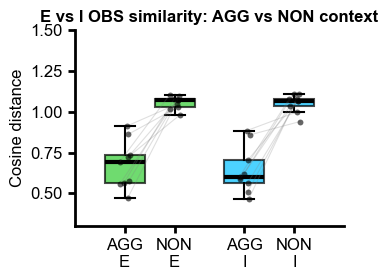

OBS-AGG: E vs I         paired t-test          stat=     1.007  df=   8  p_raw=3.4329e-01  p_fdr=3.4329e-01 ns    n=  9
E: OBS-AGG vs NON       paired t-test          stat=    -6.904  df=   8  p_raw=1.2400e-04  p_fdr=3.2361e-04 ***   n=  9
I: OBS-AGG vs NON       paired t-test          stat=    -6.371  df=   8  p_raw=2.1574e-04  p_fdr=3.2361e-04 ***   n=  9


In [1060]:
from scipy.stats import ttest_rel, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests

plt.rcParams['font.family'] = 'Arial'

# --- Define idxs ---
I_idxs = np.array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21])
E_idxs = np.array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 20])

# --- Extract E vs I similarities ---
E_obs_aggro = obs_aggro[:, E_idxs]
E_obs_non   = obs_non[:, E_idxs]
I_obs_aggro = obs_aggro[:, I_idxs]
I_obs_non   = obs_non[:, I_idxs]

distb_EA = np.nanmedian(E_obs_aggro, axis=(0,1,3)).flatten()
distb_EN = np.nanmedian(E_obs_non,   axis=(0,1,3)).flatten()
distb_IA = np.nanmedian(I_obs_aggro, axis=(0,1,3)).flatten()
distb_IN = np.nanmedian(I_obs_non,   axis=(0,1,3)).flatten()

# --- Paired stats: 3 comparisons, same 9 OBS animals throughout ─────────────
def adaptive_paired_test(a, b, alternative='two-sided', alpha=0.05):
    """
    Paired comparison: same subjects contribute both a and b.
    Normality of the DIFFERENCES gates paired t-test vs Wilcoxon signed-rank.
    """
    diffs = a - b
    n = len(diffs)

    if n >= 3:
        _, p_norm = shapiro(diffs)
        normal_diffs = p_norm > alpha
    else:
        normal_diffs = False
        p_norm = np.nan

    if normal_diffs:
        stat, p = ttest_rel(a, b, alternative=alternative)
        test_type = 'paired t-test'
        df = n - 1
    else:
        try:
            stat, p = wilcoxon(a, b, alternative=alternative,
                               zero_method='wilcox', mode='auto')
        except ValueError:
            stat, p = np.nan, np.nan
        test_type = 'Wilcoxon signed-rank'
        df = np.nan

    return stat, p, test_type, df, p_norm


# only 3 comparisons — OBS-NON: E vs I dropped (not of interest)
comparisons = {
    'OBS-AGG: E vs I':    (distb_EA, distb_IA),
    'E: OBS-AGG vs NON':  (distb_EA, distb_EN),
    'I: OBS-AGG vs NON':  (distb_IA, distb_IN),
}

raw_p, stats_out = [], []
for label, (a, b) in comparisons.items():
    stat, p, test, df, norm_p = adaptive_paired_test(a, b)
    raw_p.append(p)
    stats_out.append({'label': label, 'stat': stat, 'p_raw': p, 'test': test,
                      'df': df, 'norm_p': norm_p, 'n': len(a)})

valid_idx = [i for i, p in enumerate(raw_p) if not np.isnan(p)]
p_corrected = np.full(len(raw_p), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests([raw_p[i] for i in valid_idx], method='fdr_bh')
    for rank, i in enumerate(valid_idx):
        p_corrected[i] = corr[rank]

for i, d in enumerate(stats_out):
    d['p_fdr'] = p_corrected[i]
    df_str = f'{d["df"]:.0f}' if not np.isnan(d['df']) else 'n/a'
    print(f"{d['label']:22s}  {d['test']:<22} stat={d['stat']:>8.3f}  df={df_str:>4}  "
          f"norm_p={d['norm_p']:.4f}  n={d['n']}  "
          f"p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f}")

# --- Plot: boxplot + individual animal overlay ───────────────────────────────
fig, ax_bar = plt.subplots(figsize=(4, 3.35))

box_data      = [distb_EA, distb_EN, distb_IA, distb_IN]
box_positions = [0, 0.5, 1.2, 1.7]
box_colors    = ['limegreen', 'limegreen', 'deepskyblue', 'deepskyblue']
xlabels       = ['AGG\nE', 'NON\nE', 'AGG\nI', 'NON\nI']

bp = ax_bar.boxplot(box_data, positions=box_positions, widths=0.4,
                    patch_artist=True,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=3),
                    boxprops=dict(linewidth=1.5, edgecolor='black'),
                    whiskerprops=dict(linewidth=1.5, color='black'),
                    capprops=dict(linewidth=1.5, color='black'))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_bar.set_xticks(box_positions)
ax_bar.set_xticklabels(xlabels, fontsize=11)

# ── overlay individual animals, jittered, with light lines connecting paired points ──
rng = np.random.default_rng(42)
n_animals = len(distb_EA)
jitter_by_animal = rng.uniform(-0.06, 0.06, size=n_animals)

for xpos, data in zip(box_positions, box_data):
    ax_bar.scatter(np.full(n_animals, xpos) + jitter_by_animal, data,
                   color='black', s=18, alpha=0.6, zorder=5, linewidths=0)

# connect paired animals within each of the 3 tested comparisons
pair_connections = [
    (0, 1),   # AGG E vs NON E
    (2, 3),   # AGG I vs NON I
]
for i1, i2 in pair_connections:
    x1, x2 = box_positions[i1], box_positions[i2]
    d1, d2 = box_data[i1], box_data[i2]
    for a in range(n_animals):
        ax_bar.plot([x1 + jitter_by_animal[a], x2 + jitter_by_animal[a]],
                   [d1[a], d2[a]], color='gray', alpha=0.25, linewidth=0.8, zorder=3)

def draw_bracket(ax, x1, x2, y, p, h=0.005):
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           sig = 'ns'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11)

def whisker_top(d):
    q1, q3 = np.percentile(d, [25, 75])
    iqr = q3 - q1
    return min(np.max(d), q3 + 1.5 * iqr)

ymax = max(whisker_top(d) for d in box_data)
step = ymax * 0.06

# draw_bracket(ax_bar, box_positions[0], box_positions[2], ymax + step,   stats_out[0]['p_fdr'])
# draw_bracket(ax_bar, box_positions[0], box_positions[1], ymax + step*3, stats_out[1]['p_fdr'])
# draw_bracket(ax_bar, box_positions[2], box_positions[3], ymax + step*5, stats_out[2]['p_fdr'])

ax_bar.set_ylabel('Cosine distance', fontsize=12)
ax_bar.set_title('E vs I OBS similarity: AGG vs NON context',
                 fontsize=12, fontweight='bold')

ax_bar.tick_params(axis='both', labelsize=12, width=2, length=5)
for spine in ax_bar.spines.values():
    spine.set_linewidth(2)

plt.ylim(bottom=0.3, top=1.5)
sns.despine(ax=ax_bar)
plt.tight_layout()
plt.savefig('.\\figures\\fig4_obs_non_aggro_E_vs_I_comparison_TP.svg', dpi=300)
plt.show()

# --- Print summary ────────────────────────────────────────────────────────────
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

for i, d in enumerate(stats_out):
    label = d['label']
    a, b  = list(comparisons.values())[i]
    sig   = get_sig(d['p_fdr'])
    df_str = f'{d["df"]:.0f}' if not np.isnan(d['df']) else 'n/a'
    print(f"{label:<22}  {d['test']:<22} stat={d['stat']:>10.3f}  df={df_str:>4}  "
          f"p_raw={d['p_raw']:.4e}  p_fdr={d['p_fdr']:.4e} {sig:<4}  "
          f"n={d['n']:>3}")

In [1076]:
stat_by_label = {d['label']: d for d in stats_out}

rows = []

for channel_label, agg_vals, non_vals, comp_label in [
    ('E', distb_EA, distb_EN, 'E: OBS-AGG vs NON'),
    ('I', distb_IA, distb_IN, 'I: OBS-AGG vs NON'),
]:
    sr = stat_by_label[comp_label]
    for animal_idx in range(len(agg_vals)):
        rows.append({
            'channel': channel_label,
            'animal_idx': animal_idx,
            'AGG_context_cosine_distance': agg_vals[animal_idx],
            'NON_context_cosine_distance': non_vals[animal_idx],
            'test_type': sr['test'],
            'stat': sr['stat'],
            'df': sr['df'],
            'n_paired_animals': sr['n'],
            'p_raw': sr['p_raw'],
            'p_fdr': sr['p_fdr'],
        })

# ── E vs I (AGG-context only) comparison — separate structure, not paired
#    against the same axis as above; kept as its own block with its own stats
sr_ei = stat_by_label['OBS-AGG: E vs I']
for animal_idx in range(len(distb_EA)):
    rows.append({
        'channel': 'E_vs_I_AGG_context',
        'animal_idx': animal_idx,
        'AGG_context_cosine_distance': distb_EA[animal_idx],
        'NON_context_cosine_distance': distb_IA[animal_idx],  # here "NON_context" col actually holds I-channel AGG value — see note below
        'test_type': sr_ei['test'],
        'stat': sr_ei['stat'],
        'df': sr_ei['df'],
        'n_paired_animals': sr_ei['n'],
        'p_raw': sr_ei['p_raw'],
        'p_fdr': sr_ei['p_fdr'],
    })

sourceData_4g_right = pd.DataFrame(rows)
sourceData_4g_right.to_csv('./sourceData/4g_left.csv', index=False) 